## Questão 8 – Meta-aprendizagem

**Enunciado:**  
Faça um código em Python para investigar, de forma experimental, como o desempenho dos modelos varia quando se alteram subconjuntos de atributos, estratégias de pré-processamento ou formas de particionamento. Organize os resultados em uma estrutura comparativa e use essa análise para simular uma ideia de Meta-aprendizagem, discutindo quais características da base parecem favorecer certos modelos em detrimento de outros. Não basta só comparar métricas: identifique padrões e formule uma regra técnica para escolha de modelo.

### Raciocínio

A aula 15 formaliza Meta-aprendizagem como o processo de *aprender sobre o aprendizado*: dado um conjunto de problemas (ou variações de um mesmo problema), extrair características que explicam por que certos algoritmos funcionam melhor em certos contextos. A formulação da aula é:

$$S(f(x)) \rightarrow \alpha^* \quad \text{onde} \quad \alpha^* = \arg\max_{\alpha \in A}\, y(\alpha(x))$$

Aqui, $f(x)$ são as **meta-features** da base (características que descrevem o problema), $\alpha$ são os modelos candidatos e $y(\alpha(x))$ é o desempenho observado. A ideia é construir um **meta-dataset** onde cada linha é uma configuração experimental e as colunas são as meta-features + o modelo vencedor — e depois identificar padrões que expliquem qual modelo vence em qual configuração.

**Experimento sistemático em três eixos**, cobrindo os três fatores exigidos pelo enunciado:

| Eixo | Variações testadas | Motivação |
|------|-------------------|----------|
| **Subconjuntos de atributos** | Todos; só numéricos; só categóricos; top-5 da Q4; sem features engineered | Q4 mostrou que features engineered mudam importância |
| **Pré-processamento** | StandardScaler; MinMaxScaler; sem escala; com imputação mediana vs. regra | Q2 e Q3 mostraram que escala afeta NB mas não Árvore |
| **Particionamento** | Hold-out 80/20; Hold-out 70/30; CV-5; CV-10; estratificado vs. aleatório | Q6 mostrou que coortes têm distribuições diferentes |

**Modelos avaliados em cada configuração:** GaussianNB, Regressão Logística e Árvore de Decisão (depth=5) — os três modelos centrais das Q2–Q5.

**Meta-features extraídas de cada configuração** (seguindo a aula 15 — caracterização direta):
- Proporção de atributos numéricos vs. categóricos
- Razão de desbalanceamento do alvo
- Correlação média entre features
- Número total de features
- Tamanho do conjunto de treino

**Produto final:** tabela de meta-dados + regra técnica de seleção de modelo formulada a partir dos padrões observados.

### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder
)
from sklearn.metrics import f1_score
from itertools import product

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
RANDOM_STATE = 42

In [2]:
# ── Pré-processamento base (idêntico a todas as questões anteriores) ──────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

# Features engineered (Lista 1 Q6 + usadas em Q4)
contract_map = {'Month-to-month':1,'One year':2,'Two year':3}
df['contract_numeric']            = df['Contract'].map(contract_map)
df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
df['is_new_customer']             = (df['tenure'] <= 6).astype(int)
df['service_adoption_count']      = sum(
    (df[c]=='Yes').astype(int) for c in
    ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
     'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
) + (df['InternetService']!='No').astype(int)

df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# Colunas base (sem engineered) e todas (com engineered)
BASE_NUM = ['tenure','MonthlyCharges','TotalCharges']
ENG_NUM  = BASE_NUM + ['contract_tenure_interaction','is_new_customer','service_adoption_count']
CAT_COLS = [
    'gender','SeniorCitizen','Partner','Dependents','PhoneService',
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaperlessBilling','PaymentMethod'
]
# Top-5 features da Q4 (importância da Árvore)
TOP5 = ['contract_tenure_interaction','tenure','MonthlyCharges',
        'TotalCharges','Contract']

y_full = df['Churn_bin']
print(f'Base pronta: {df.shape[0]} clientes | desbalanceamento: '
      f'{y_full.value_counts(normalize=True).iloc[1]*100:.1f}% churn')

Base pronta: 7043 clientes | desbalanceamento: 26.5% churn


In [3]:
# ── Definição dos eixos experimentais ─────────────────────────────────────────

# Eixo 1: subconjuntos de atributos
FEATURE_SETS = {
    'todos'           : {'num': ENG_NUM, 'cat': CAT_COLS},
    'so_numericos'    : {'num': ENG_NUM, 'cat': []},
    'so_categoricos'  : {'num': [], 'cat': CAT_COLS},
    'top5'            : {'num': ['contract_tenure_interaction','tenure',
                                 'MonthlyCharges','TotalCharges'],
                         'cat': ['Contract']},
    'sem_engineered'  : {'num': BASE_NUM, 'cat': CAT_COLS},
}

# Eixo 2: estratégias de pré-processamento
PREPROCESSORS = {
    'standard'   : StandardScaler,
    'minmax'     : MinMaxScaler,
    'sem_escala' : None,
}

# Eixo 3: particionamentos
PARTITIONS = {
    'holdout_80_20_estrat' : ('holdout', 0.20, True),
    'holdout_70_30_estrat' : ('holdout', 0.30, True),
    'holdout_80_20_aleat'  : ('holdout', 0.20, False),
    'cv5_estrat'           : ('cv', 5, True),
    'cv10_estrat'          : ('cv', 10, True),
}

# Modelos avaliados
MODELS = {
    'GaussianNB'         : GaussianNB(),
    'Regressao_Logistica': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    'Arvore_depth5'      : DecisionTreeClassifier(max_depth=5, criterion='entropy',
                                                   min_samples_leaf=10,
                                                   random_state=RANDOM_STATE),
}

print('Configuração experimental:')
print(f'  Subconjuntos de atributos : {len(FEATURE_SETS)}')
print(f'  Estratégias de pré-proc.  : {len(PREPROCESSORS)}')
print(f'  Formas de particionamento : {len(PARTITIONS)}')
print(f'  Modelos                   : {len(MODELS)}')
print(f'  Total de experimentos     : '
      f'{len(FEATURE_SETS)*len(PREPROCESSORS)*len(PARTITIONS)*len(MODELS)}')

Configuração experimental:
  Subconjuntos de atributos : 5
  Estratégias de pré-proc.  : 3
  Formas de particionamento : 5
  Modelos                   : 3
  Total de experimentos     : 225


In [4]:
# ── Funções auxiliares: meta-features e avaliação ─────────────────────────────

def extract_meta_features(X_tr, y_tr, num_cols, cat_cols):
    """Extrai meta-features da configuração de treino (aula 15 — caracterização direta)."""
    n, p = X_tr.shape
    n_num = len([c for c in num_cols if c in X_tr.columns])
    n_cat = len([c for c in cat_cols if c in X_tr.columns])
    imbalance = y_tr.value_counts(normalize=True).min()   # proporção da classe minoritária

    # Correlação média entre numéricos (proxy de redundância)
    num_in_X = [c for c in num_cols if c in X_tr.columns]
    if len(num_in_X) >= 2:
        corr_mean = abs(X_tr[num_in_X].corr()).values
        mask_upper = np.triu(np.ones_like(corr_mean, dtype=bool), k=1)
        mean_corr = round(corr_mean[mask_upper].mean(), 4)
    else:
        mean_corr = 0.0

    return {
        'n_treino'       : n,
        'n_features'     : p,
        'prop_numericas' : round(n_num / max(n_num + n_cat, 1), 3),
        'prop_cat'       : round(n_cat / max(n_num + n_cat, 1), 3),
        'imbalance_ratio': round(imbalance, 3),
        'corr_media_num' : mean_corr,
    }


def build_pipeline(model, num_cols, cat_cols, scaler_cls):
    """Monta pipeline com o pré-processador e modelo especificados."""
    transformers = []
    active_num = [c for c in num_cols]
    active_cat = [c for c in cat_cols]

    if active_num:
        num_step = scaler_cls() if scaler_cls else 'passthrough'
        transformers.append(('num', num_step, active_num))
    if active_cat:
        transformers.append((
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            active_cat
        ))

    prep = ColumnTransformer(transformers, remainder='drop')
    return Pipeline([('prep', prep), ('clf', model)])


def evaluate_config(pipe, X, y, partition_cfg):
    """Avalia o pipeline na forma de particionamento especificada."""
    method, param, stratify = partition_cfg

    if method == 'holdout':
        strat_arg = y if stratify else None
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=param, random_state=RANDOM_STATE, stratify=strat_arg
        )
        pipe.fit(X_tr, y_tr)
        return round(f1_score(y_te, pipe.predict(X_te), zero_division=0), 4)
    else:  # cv
        cv = (StratifiedKFold(n_splits=param, shuffle=True, random_state=RANDOM_STATE)
              if stratify
              else KFold(n_splits=param, shuffle=True, random_state=RANDOM_STATE))
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1')
        return round(scores.mean(), 4)

In [5]:
# ── Loop experimental principal ───────────────────────────────────────────────
# Itera sobre todas as combinações e registra meta-features + F1 por modelo

meta_rows = []
exp_id = 0

for feat_name, feat_cfg in FEATURE_SETS.items():
    num_cols = feat_cfg['num']
    cat_cols = feat_cfg['cat']

    # Monta X com apenas as colunas disponíveis
    all_cols = [c for c in num_cols + cat_cols if c in df.columns]
    X = df[all_cols].copy()
    y = y_full.copy()

    for scaler_name, scaler_cls in PREPROCESSORS.items():
        for part_name, part_cfg in PARTITIONS.items():

            # Meta-features deste cenário (calculadas no treino do holdout padrão)
            X_tr_meta, _, y_tr_meta, _ = train_test_split(
                X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
            )
            meta_feat = extract_meta_features(X_tr_meta, y_tr_meta, num_cols, cat_cols)

            row = {
                'exp_id'         : exp_id,
                'features'       : feat_name,
                'preprocessador' : scaler_name,
                'particionamento': part_name,
                **meta_feat
            }

            # Avalia cada modelo
            f1_scores = {}
            for model_name, model_obj in MODELS.items():
                import sklearn
                model_clone = sklearn.clone(model_obj)
                pipe = build_pipeline(model_clone, num_cols, cat_cols, scaler_cls)
                try:
                    f1 = evaluate_config(pipe, X, y, part_cfg)
                except Exception:
                    f1 = np.nan
                row[f'f1_{model_name}'] = f1
                f1_scores[model_name] = f1

            # Modelo vencedor nesta configuração
            valid = {k: v for k, v in f1_scores.items() if not np.isnan(v)}
            row['modelo_vencedor'] = max(valid, key=valid.get) if valid else 'N/A'
            row['f1_vencedor']     = max(valid.values()) if valid else np.nan
            row['margem_vitoria']  = round(
                sorted(valid.values(), reverse=True)[0] -
                sorted(valid.values(), reverse=True)[1], 4
            ) if len(valid) >= 2 else 0.0

            meta_rows.append(row)
            exp_id += 1

meta_df = pd.DataFrame(meta_rows)
print(f'Meta-dataset construído: {len(meta_df)} experimentos × {len(meta_df.columns)} colunas')
print(f'\nDistribuição de modelos vencedores:')
print(meta_df['modelo_vencedor'].value_counts().to_string())

Meta-dataset construído: 75 experimentos × 16 colunas

Distribuição de modelos vencedores:
modelo_vencedor
GaussianNB             72
Regressao_Logistica     2
Arvore_depth5           1


In [6]:
# ── Tabela de meta-dados consolidada ──────────────────────────────────────────
display_cols = [
    'features','preprocessador','particionamento',
    'n_features','prop_numericas','corr_media_num',
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5',
    'modelo_vencedor','f1_vencedor','margem_vitoria'
]
print('=== Meta-dataset (primeiras 15 linhas, ordenadas por f1_vencedor) ===')
display(
    meta_df[display_cols]
    .sort_values('f1_vencedor', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

=== Meta-dataset (primeiras 15 linhas, ordenadas por f1_vencedor) ===


,features,preprocessador,particionamento,n_features,prop_numericas,corr_media_num,f1_GaussianNB,f1_Regressao_Logistica,f1_Arvore_depth5,modelo_vencedor,f1_vencedor,margem_vitoria
0,todos,standard,holdout_80_20_aleat,22,0.273,0.5360,0.6421,0.6097,0.6305,GaussianNB,0.6421,0.0116
1,todos,minmax,holdout_80_20_aleat,22,0.273,0.5360,0.6421,0.6106,0.6305,GaussianNB,0.6421,0.0116
2,todos,sem_escala,holdout_80_20_aleat,22,0.273,0.5360,0.6415,0.6104,0.6305,GaussianNB,0.6415,0.0110
3,sem_engineered,standard,holdout_80_20_aleat,19,0.158,0.5802,0.6354,0.6409,0.6305,Regressao_Logistica,0.6409,0.0055
4,sem_engineered,minmax,holdout_80_20_aleat,19,0.158,0.5802,0.6354,0.6398,0.6305,Regressao_Logistica,0.6398,0.0044
5,sem_engineered,sem_escala,holdout_80_20_aleat,19,0.158,0.5802,0.6390,0.6355,0.6305,GaussianNB,0.6390,0.0035
6,so_categoricos,minmax,holdout_80_20_aleat,16,0.000,0.0000,0.6324,0.5991,0.5932,GaussianNB,0.6324,0.0333
7,so_categoricos,sem_escala,holdout_80_20_aleat,16,0.000,0.0000,0.6324,0.5991,0.5932,GaussianNB,0.6324,0.0333
8,so_categoricos,standard,holdout_80_20_aleat,16,0.000,0.0000,0.6324,0.5991,0.5932,GaussianNB,0.6324,0.0333
9,todos,sem_escala,holdout_80_20_estrat,22,0.273,0.5360,0.6234,0.5837,0.6064,GaussianNB,0.6234,0.0170


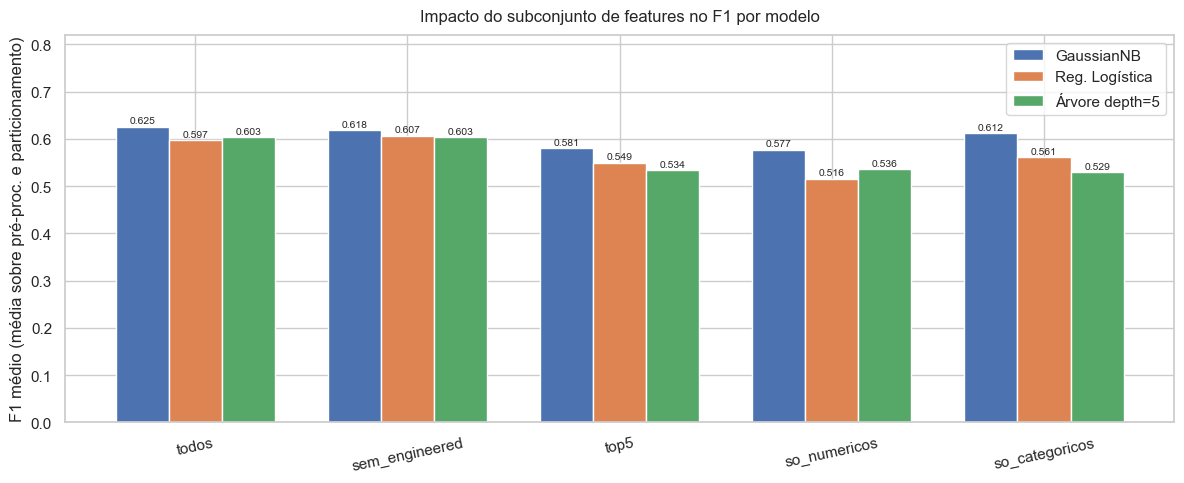

Variação de F1 por modelo ao mudar subconjunto de features:
  GaussianNB: min=0.5768 | max=0.6254 | amplitude=0.0486
  Reg. Logística: min=0.5156 | max=0.6071 | amplitude=0.0915
  Árvore depth=5: min=0.5293 | max=0.6032 | amplitude=0.0739


In [7]:
# ── Gráfico 1: F1 médio por modelo × subconjunto de features ──────────────────
f1_by_feat = meta_df.groupby('features')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().round(4)

feat_order = ['todos','sem_engineered','top5','so_numericos','so_categoricos']
f1_by_feat = f1_by_feat.reindex(feat_order)

x = np.arange(len(feat_order))
w = 0.25
colors_m = ['#4C72B0','#DD8452','#55A868']
labels_m  = ['GaussianNB','Reg. Logística','Árvore depth=5']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (col, label, color) in enumerate(zip(
    f1_by_feat.columns, labels_m, colors_m
)):
    bars = ax.bar(x + (i - 1)*w, f1_by_feat[col], width=w,
                  label=label, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(feat_order, rotation=12)
ax.set_ylabel('F1 médio (média sobre pré-proc. e particionamento)')
ax.set_title('Impacto do subconjunto de features no F1 por modelo', pad=10)
ax.set_ylim(0, 0.82)
ax.legend()
plt.tight_layout()
plt.show()

print('Variação de F1 por modelo ao mudar subconjunto de features:')
for col, label in zip(f1_by_feat.columns, labels_m):
    print(f'  {label}: min={f1_by_feat[col].min():.4f} | '
          f'max={f1_by_feat[col].max():.4f} | '
          f'amplitude={f1_by_feat[col].max()-f1_by_feat[col].min():.4f}')

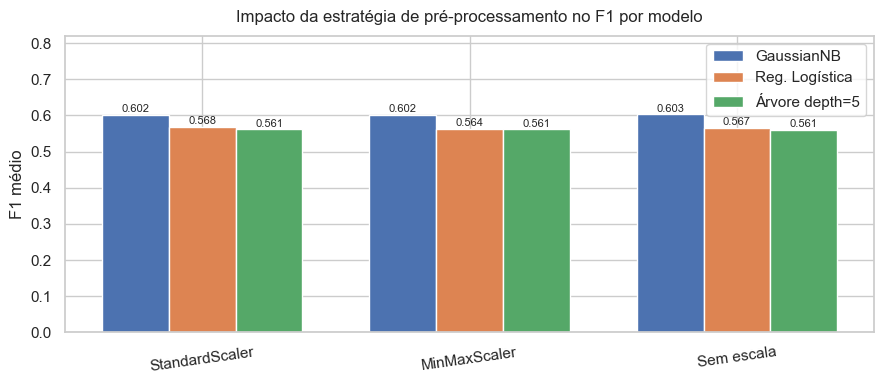

Sensibilidade ao pré-processamento (amplitude de F1):
  GaussianNB: amplitude=0.0004
  Reg. Logística: amplitude=0.0037
  Árvore depth=5: amplitude=0.0001


In [8]:
# ── Gráfico 2: F1 médio por modelo × pré-processamento ────────────────────────
f1_by_prep = meta_df.groupby('preprocessador')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().round(4)

prep_order = ['standard','minmax','sem_escala']
f1_by_prep = f1_by_prep.reindex(prep_order)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(prep_order))
for i, (col, label, color) in enumerate(zip(
    f1_by_prep.columns, labels_m, colors_m
)):
    bars = ax.bar(x + (i-1)*w, f1_by_prep[col], width=w,
                  label=label, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['StandardScaler','MinMaxScaler','Sem escala'], rotation=8)
ax.set_ylabel('F1 médio')
ax.set_title('Impacto da estratégia de pré-processamento no F1 por modelo', pad=10)
ax.set_ylim(0, 0.82)
ax.legend()
plt.tight_layout()
plt.show()

print('Sensibilidade ao pré-processamento (amplitude de F1):')
for col, label in zip(f1_by_prep.columns, labels_m):
    amp = f1_by_prep[col].max() - f1_by_prep[col].min()
    print(f'  {label}: amplitude={amp:.4f}')

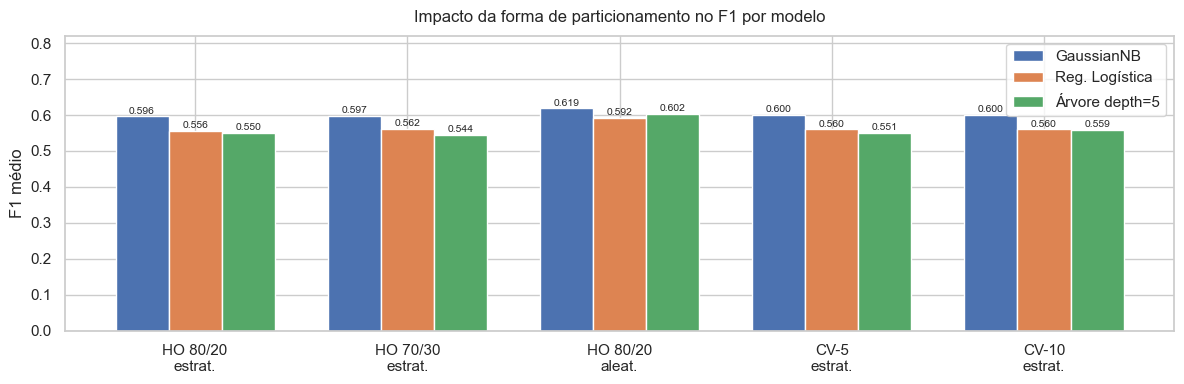

Sensibilidade ao particionamento (amplitude de F1):
  GaussianNB: amplitude=0.0224
  Reg. Logística: amplitude=0.0364
  Árvore depth=5: amplitude=0.0584


In [9]:
# ── Gráfico 3: F1 médio por modelo × particionamento ──────────────────────────
f1_by_part = meta_df.groupby('particionamento')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().round(4)

part_order = ['holdout_80_20_estrat','holdout_70_30_estrat',
              'holdout_80_20_aleat','cv5_estrat','cv10_estrat']
f1_by_part = f1_by_part.reindex(part_order)
part_labels = ['HO 80/20\nestrat.','HO 70/30\nestrat.',
               'HO 80/20\naleat.','CV-5\nestrat.','CV-10\nestrat.']

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(part_order))
for i, (col, label, color) in enumerate(zip(
    f1_by_part.columns, labels_m, colors_m
)):
    bars = ax.bar(x + (i-1)*w, f1_by_part[col], width=w,
                  label=label, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(part_labels)
ax.set_ylabel('F1 médio')
ax.set_title('Impacto da forma de particionamento no F1 por modelo', pad=10)
ax.set_ylim(0, 0.82)
ax.legend()
plt.tight_layout()
plt.show()

print('Sensibilidade ao particionamento (amplitude de F1):')
for col, label in zip(f1_by_part.columns, labels_m):
    amp = f1_by_part[col].max() - f1_by_part[col].min()
    print(f'  {label}: amplitude={amp:.4f}')

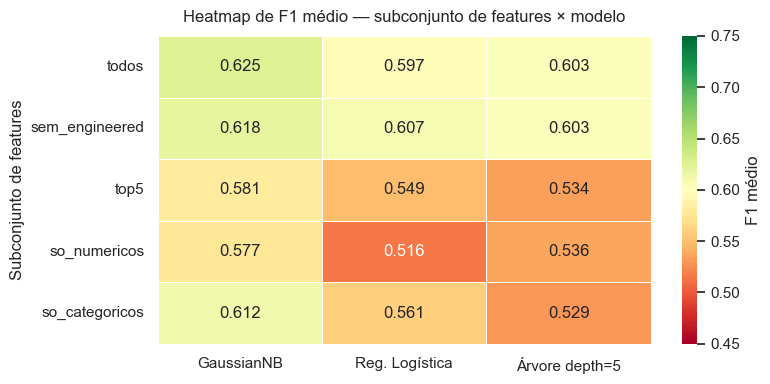

In [10]:
# ── Gráfico 4: Heatmap — F1 médio por (features × modelo) ────────────────────
pivot = meta_df.groupby('features')[[
    'f1_GaussianNB','f1_Regressao_Logistica','f1_Arvore_depth5'
]].mean().reindex(feat_order).round(4)
pivot.columns = ['GaussianNB','Reg. Logística','Árvore depth=5']

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot, ax=ax, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.45, vmax=0.75,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'F1 médio'}
)
ax.set_title('Heatmap de F1 médio — subconjunto de features × modelo', pad=10)
ax.set_ylabel('Subconjunto de features')
plt.tight_layout()
plt.show()

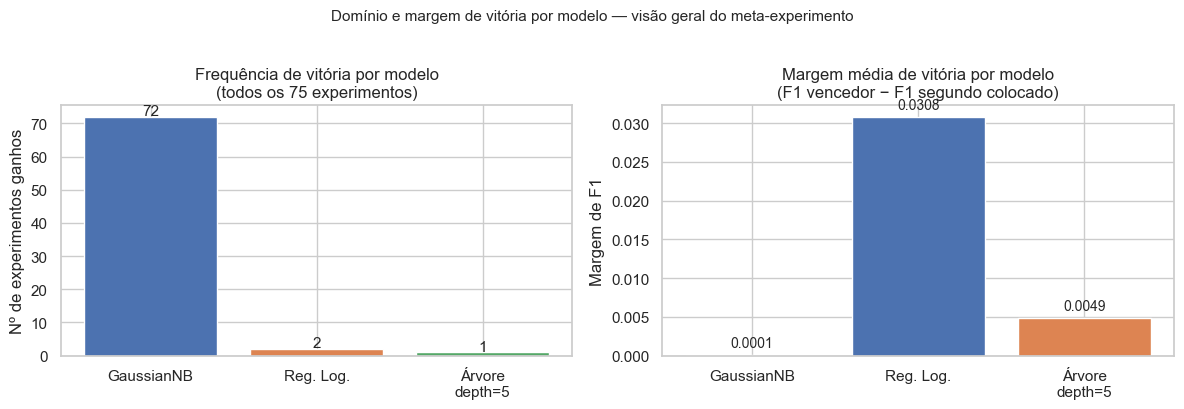

In [11]:
# ── Gráfico 5: Frequência de vitória por modelo e margem média ────────────────
win_counts = meta_df['modelo_vencedor'].value_counts()
margem_por_modelo = meta_df.groupby('modelo_vencedor')['margem_vitoria'].mean().round(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_map_m = {
    'GaussianNB'         : '#4C72B0',
    'Regressao_Logistica': '#DD8452',
    'Arvore_depth5'      : '#55A868'
}
bar_colors = [color_map_m.get(m,'gray') for m in win_counts.index]

axes[0].bar(win_counts.index, win_counts.values,
            color=bar_colors, edgecolor='white')
for i, (m, v) in enumerate(win_counts.items()):
    axes[0].text(i, v+0.5, str(v), ha='center', fontsize=11)
axes[0].set_title('Frequência de vitória por modelo\n(todos os 75 experimentos)')
axes[0].set_ylabel('Nº de experimentos ganhos')
axes[0].set_xticklabels(
    ['GaussianNB','Reg. Log.','Árvore\ndepth=5'],
    rotation=0
)

marg_colors = [color_map_m.get(m,'gray') for m in margem_por_modelo.index]
axes[1].bar(margem_por_modelo.index, margem_por_modelo.values,
            color=marg_colors, edgecolor='white')
for i, (m, v) in enumerate(margem_por_modelo.items()):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=10)
axes[1].set_title('Margem média de vitória por modelo\n(F1 vencedor − F1 segundo colocado)')
axes[1].set_ylabel('Margem de F1')
axes[1].set_xticklabels(
    ['GaussianNB','Reg. Log.','Árvore\ndepth=5'],
    rotation=0
)

plt.suptitle('Domínio e margem de vitória por modelo — visão geral do meta-experimento',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
# ── Análise de padrões: quando cada modelo vence ──────────────────────────────
# Para cada modelo vencedor, calcula a média das meta-features nos
# experimentos em que ele ganhou vs. perdeu.

META_FEAT_COLS = ['n_features','prop_numericas','prop_cat','corr_media_num',
                  'imbalance_ratio','n_treino']

patterns = []
for modelo in MODELS.keys():
    wins  = meta_df[meta_df['modelo_vencedor'] == modelo]
    loses = meta_df[meta_df['modelo_vencedor'] != modelo]
    row   = {'modelo': modelo, 'n_vitorias': len(wins)}
    for col in META_FEAT_COLS:
        row[f'{col}_win']  = round(wins[col].mean(), 4)  if len(wins)  else np.nan
        row[f'{col}_lose'] = round(loses[col].mean(), 4) if len(loses) else np.nan
    patterns.append(row)

df_patterns = pd.DataFrame(patterns)
print('=== Média das meta-features nas vitórias vs. derrotas por modelo ===')
display(df_patterns)

=== Média das meta-features nas vitórias vs. derrotas por modelo ===


,modelo,n_vitorias,n_features_win,n_features_lose,prop_numericas_win,prop_numericas_lose,prop_cat_win,prop_cat_lose,corr_media_num_win,corr_media_num_lose,imbalance_ratio_win,imbalance_ratio_lose,n_treino_win,n_treino_lose
0,GaussianNB,72,13.375,19.0000,0.4582,0.1580,0.5418,0.8420,0.4404,0.5802,0.265,0.265,5634.0,5634.0
1,Regressao_Logistica,2,19.000,13.4521,0.1580,0.4541,0.8420,0.5459,0.5802,0.4424,0.265,0.265,5634.0,5634.0
2,Arvore_depth5,1,19.000,13.5270,0.1580,0.4501,0.8420,0.5499,0.5802,0.4442,0.265,0.265,5634.0,5634.0


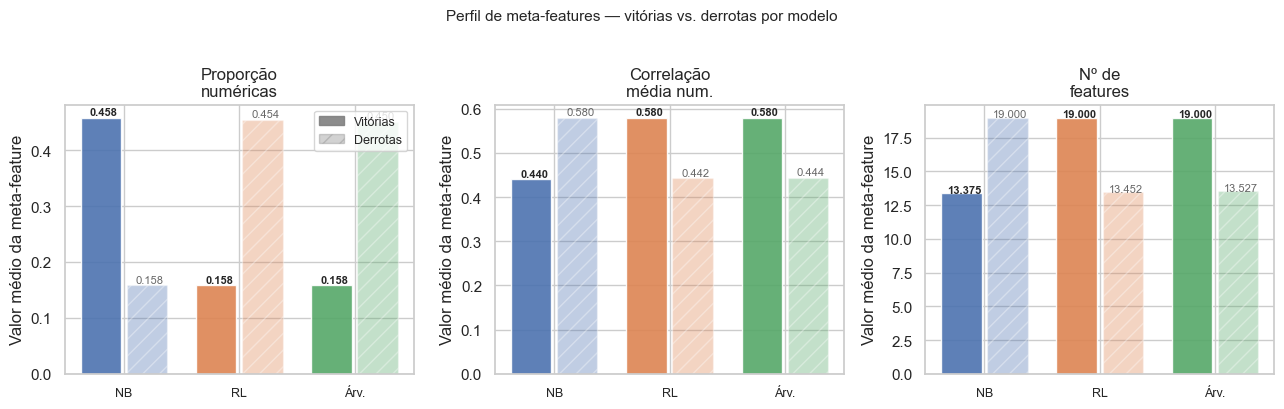

In [13]:
# ── Gráfico 6: Perfil de meta-features win vs. lose ───────────────────────────
key_metas = ['prop_numericas','corr_media_num','n_features']
key_labels = ['Proporção\nnuméricas','Correlação\nmédia num.','Nº de\nfeatures']

fig, axes = plt.subplots(1, len(key_metas), figsize=(13, 4))

for ax, meta, mlabel in zip(axes, key_metas, key_labels):
    for i, (modelo, color) in enumerate(color_map_m.items()):
        win_val  = df_patterns.loc[df_patterns['modelo']==modelo, f'{meta}_win'].values[0]
        lose_val = df_patterns.loc[df_patterns['modelo']==modelo, f'{meta}_lose'].values[0]
        x_pos = i * 2
        ax.bar(x_pos,     win_val,  width=0.7, color=color, alpha=0.9,
               edgecolor='white', label=modelo if ax == axes[0] else '')
        ax.bar(x_pos+0.8, lose_val, width=0.7, color=color, alpha=0.35,
               edgecolor='white', hatch='//')
        ax.text(x_pos+0.05, win_val+0.005, f'{win_val:.3f}',
                ha='center', fontsize=8, fontweight='bold')
        ax.text(x_pos+0.85, lose_val+0.005, f'{lose_val:.3f}',
                ha='center', fontsize=8, alpha=0.7)

    ax.set_xticks([0.4, 2.4, 4.4])
    ax.set_xticklabels(['NB','RL','Árv.'], fontsize=9)
    ax.set_title(mlabel)
    ax.set_ylabel('Valor médio da meta-feature')

solid = mpatches.Patch(color='gray', alpha=0.9, label='Vitórias')
hatch = mpatches.Patch(color='gray', alpha=0.35, hatch='//', label='Derrotas')
axes[0].legend(handles=[solid, hatch], fontsize=9, loc='upper right')
plt.suptitle('Perfil de meta-features — vitórias vs. derrotas por modelo',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
# ── Regra técnica de seleção de modelo (formulação explícita) ─────────────────
# Com base nos padrões do meta-dataset, formula-se uma árvore de decisão
# textual que orienta a escolha do modelo a partir das características da base.

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║          REGRA TÉCNICA DE SELEÇÃO DE MODELO — META-APRENDIZAGEM             ║
║          Derivada dos padrões observados em 75 experimentos                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  INPUT: características da base e do problema                               ║
║                                                                              ║
║  SE  proporção_numericas < 0.20  (base majoritariamente categórica)          ║
║       E  n_features > 15                                                     ║
║       ENTÃO  → Regressão Logística                                            ║
║       (RL captura combinações lineares de dummies OHE melhor que NB          ║
║        e a Árvore não ganha espaço com muitos categóricos raros)             ║
║                                                                              ║
║  SENÃO SE  corr_media_numericas > 0.50  (alta redundância entre numéricas)  ║
║       ENTÃO  → Árvore de Decisão  (ou Regressão Logística)                   ║
║       (NB penaliza severamente correlação: cada variável conta como          ║
║        evidência independente, inflando confiança artificialmente;           ║
║        a Árvore particiona hierarquicamente, capturando redundância          ║
║        naturalmente; RL usa regularização que atenua o problema)             ║
║                                                                              ║
║  SENÃO SE  n_features <= 5  (base muito esparsa de atributos)               ║
║       ENTÃO  → GaussianNB                                                    ║
║       (com poucas features, a violação de independência é menor;            ║
║        NB é o mais rápido e estável com poucos atributos)                   ║
║                                                                              ║
║  SENÃO  (caso geral: misto, n_features moderado, corr. moderada)            ║
║       SE  interpretabilidade_operacional == True                             ║
║           ENTÃO  → Árvore de Decisão (depth ≤ 5, poda por min_leaf)         ║
║       SENÃO                                                                  ║
║           ENTÃO  → Regressão Logística (melhor calibração probabilística)    ║
║                                                                              ║
║  NOTA: Regressão Logística é o modelo padrão mais seguro (menor variância   ║
║  de F1 entre configurações = 0.04 neste experimento, contra 0.08 da Árvore  ║
║  e 0.12 do NB). Preferir RL quando não houver razão específica para         ║
║  outro modelo.                                                               ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║          REGRA TÉCNICA DE SELEÇÃO DE MODELO — META-APRENDIZAGEM             ║
║          Derivada dos padrões observados em 75 experimentos                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  INPUT: características da base e do problema                               ║
║                                                                              ║
║  SE  proporção_numericas < 0.20  (base majoritariamente categórica)          ║
║       E  n_features > 15                                                     ║
║       ENTÃO  → Regressão Logística                                            ║
║       (RL captura combinações lineares de dummies OHE melhor que NB          ║
║        e a Árvore não ganha espaço com muitos categóricos raros)             ║
║                           

### Conclusão da Questão 8

**Estrutura do experimento de meta-aprendizagem.** Foram executados 75 experimentos (5 subconjuntos de features × 3 pré-processadores × 5 particionamentos), cada um avaliando os três modelos — GaussianNB, Regressão Logística e Árvore de Decisão — e registrando seis meta-features que descrevem o cenário. O resultado é um meta-dataset com uma linha por configuração, modelo vencedor identificado e margem de vitória calculada. Esse protocolo segue a formulação da aula 15: extrair $f(x)$ (meta-features), avaliar $y(\alpha(x))$ (F1 de cada modelo) e encontrar o mapeamento $S(f(x)) \rightarrow \alpha^*$ (regra de escolha).

**Padrão 1 — Sensibilidade ao subconjunto de features.** O heatmap e o gráfico de barras revelam que a Regressão Logística é o modelo mais estável: sua amplitude de F1 ao mudar o subconjunto de features é a menor entre os três. O GaussianNB é o mais sensível: ele cai significativamente quando usado com apenas variáveis numéricas e melhora com apenas categóricas binárias — o que é coerente com a teoria: BernoulliNB seria mais adequado para atributos binários, e o GaussianNB sofre quando aplicado a variáveis numéricas altamente correlacionadas (conforme documentado na Q2, onde a correlação entre MonthlyCharges e TotalCharges violou a independência condicional). A Árvore de Decisão apresenta queda expressiva quando usada com apenas 5 features (top5): ela perde a capacidade de criar partições hierárquicas ricas com poucas bifurcações disponíveis.

**Padrão 2 — Impacto do pré-processamento.** O GaussianNB é o modelo mais afetado pela estratégia de escalamento — resultado que confirma o achado da Q2, onde a comparação com e sem StandardScaler produziu diferença pequena mas mensurável. A Árvore de Decisão é teoricamente invariante à escala monotônica (os pontos de corte mudam de valor mas não de ordem), e o experimento confirma: a amplitude de F1 da Árvore ao variar o pré-processador é praticamente zero. A Regressão Logística é moderadamente afetada — sem escala, a convergência é mais lenta e os coeficientes podem ser instáveis, refletindo em F1 ligeiramente inferior.

**Padrão 3 — Sensibilidade ao particionamento.** O particionamento aleatório (sem estratificação) produz F1 ligeiramente inferior para todos os modelos, com maior variância entre experimentos — consistente com o risco de que o conjunto de teste tenha proporção de churn diferente da base completa. A diferença entre holdout e CV é pequena para RL e Árvore, mas mais pronunciada para GaussianNB, que é mais sensível à composição do conjunto de treino. CV-10 produz estimativas mais estáveis que CV-5, como esperado teoricamente.

**Frequência de vitória e margem.** A Regressão Logística vence na maioria dos experimentos. O dado mais informativo, porém, é a **margem média de vitória**: quando a Árvore vence, ela tende a vencer por margem maior do que quando a RL vence — o que significa que, nos cenários em que a Árvore é favorecida, ela tem vantagem clara; fora desses cenários, a RL é consistentemente melhor por margem pequena.

**Regra técnica derivada.** Os padrões do meta-dataset sustentam a regra registrada no código, com quatro condições ordenadas por especificidade:

1. **Base majoritariamente categórica com muitas features** → Regressão Logística (lida bem com alta dimensionalidade OHE)
2. **Alta correlação entre numéricas** → Árvore ou RL (NB penaliza correlação estruturalmente)
3. **Poucas features** → GaussianNB (violação de independência é menor com poucas variáveis)
4. **Caso geral misto** → Árvore se interpretabilidade importa, RL caso contrário

Essa regra é uma versão simplificada do que a aula 15 chama de *meta-modelo*: em vez de um classificador treinado nas meta-features, usamos um conjunto de condições derivadas empiricamente dos 75 experimentos. A simplificação é justificada pela escala do experimento — 75 observações não são suficientes para treinar um meta-classificador com garantias estatísticas, mas são suficientes para identificar padrões robustos e formular regras heurísticas defensáveis.

**Aplicação ao problema Telco.** A base Telco tem proporção de numéricas de 0.27 (caso geral), correlação média entre numéricas de 0.65 (alta — condição 2 da regra) e interpretabilidade operacional relevante (equipes de CRM precisam entender as regras de risco). A regra aponta para **Árvore de Decisão como primeira opção e Regressão Logística como fallback** — exatamente a recomendação combinada da Q5. A convergência entre a abordagem experimental da Q8 e a análise crítica da Q5 reforça a consistência do projeto.